# Turbofan Engine RUL Prediction

## Overview

This educational notebook demonstrates how to predict the **Remaining Useful Life (RUL)** of turbofan engines using various machine learning algorithms. RUL prediction is crucial for predictive maintenance, allowing us to schedule maintenance before engine failure occurs.

## Learning Objectives

By the end of this notebook, you will:
- Understand how to preprocess time-series engine data
- Learn feature engineering techniques for predictive maintenance
- Compare different machine learning algorithms for regression tasks
- Evaluate model performance using multiple metrics
- Interpret model results and feature importance

## Models Implemented

This notebook implements and compares the following machine learning models:
- **Linear Regression**: A baseline linear model that assumes a linear relationship between features and RUL
- **Support Vector Machine (SVM)**: A kernel-based method that can capture non-linear relationships
- **Random Forest**: An ensemble method using multiple decision trees
- **Gradient Boosting**: A sequential ensemble method that builds models to correct previous errors
- **LightGBM**: A fast, distributed gradient boosting framework optimized for efficiency


## 1. Import Libraries and Setup

### Purpose
This cell imports all necessary libraries for data manipulation, machine learning, and visualization. Understanding the libraries used is important for understanding the workflow.

### Libraries Used:
- **NumPy & Pandas**: Data manipulation and numerical operations
- **Matplotlib & Seaborn**: Data visualization
- **Scikit-learn**: Machine learning models and utilities
- **LightGBM**: Gradient boosting framework


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

# Set style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load and Prepare Data

### Purpose
Load the NASA CMAPSS turbofan engine degradation dataset. This dataset contains sensor measurements and operational settings from multiple engines over their operational lifetime.

### Dataset Information:
- **Training Data**: Contains full run-to-failure trajectories for multiple engines
- **Test Data**: Contains partial trajectories (ending before failure)
- **RUL Values**: True remaining useful life for test engines (ground truth for evaluation)

### Data Structure:
- Each row represents one operational cycle
- Each engine has multiple cycles until failure
- Features include 3 operational settings and 21 sensor measurements


In [ ]:
# Define data path
data_path = Path('dataset/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData')

# Column names with actual field names
# Operational settings: Altitude, Mach, TRA (Throttle Resolver Angle)
op_settings = ['Altitude', 'Mach', 'TRA']

# Sensor names based on CMAPSS dataset documentation
sensors = [
    'T2',      # Total temperature at fan inlet
    'T24',     # Total temperature at LPC outlet
    'T30',     # Total temperature at HPC outlet
    'T50',     # Total temperature at LPT outlet
    'P2',      # Pressure at fan inlet
    'P15',     # Total pressure in bypass-duct
    'P30',     # Total pressure at HPC outlet
    'Nf',      # Physical fan speed
    'Nc',      # Physical core speed
    'epr',     # Engine pressure ratio (P50/P2)
    'Ps30',    # Static pressure at HPC outlet
    'phi',     # Ratio of fuel flow to Ps30
    'NRf',     # Corrected fan speed
    'NRc',     # Corrected core speed
    'BPR',     # Bypass Ratio
    'farB',    # Burner fuel-air ratio
    'htBleed', # Bleed Enthalpy
    'Nf_dmd',  # Demanded fan speed
    'PCNfR_dmd', # Demanded corrected fan speed
    'W31',     # HPT coolant bleed
    'W32'      # LPT coolant bleed
]

column_names = ['unit', 'time'] + op_settings + sensors

def load_data(dataset='FD001'):
    """Load training and test data for a given dataset"""
    train_file = data_path / f'train_{dataset}.txt'
    test_file = data_path / f'test_{dataset}.txt'
    rul_file = data_path / f'RUL_{dataset}.txt'
    
    train_df = pd.read_csv(train_file, sep='\s+', header=None, names=column_names)
    test_df = pd.read_csv(test_file, sep='\s+', header=None, names=column_names)
    rul_df = pd.read_csv(rul_file, sep='\s+', header=None, names=['RUL'])
    
    return train_df, test_df, rul_df

def calculate_rul_train(df):
    """Calculate RUL for training data (countdown to failure)"""
    df = df.copy()
    df['RUL'] = df.groupby('unit')['time'].transform(lambda x: x.max() - x)
    return df

# Load FD001 dataset
train_df, test_df, rul_df = load_data('FD001')

# Calculate RUL for training data
train_df = calculate_rul_train(train_df)

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"RUL data shape: {rul_df.shape}")
print(f"\nNumber of engines in training: {train_df['unit'].nunique()}")
print(f"Number of engines in test: {test_df['unit'].nunique()}")


Training data shape: (20631, 27)
Test data shape: (13096, 26)
RUL data shape: (100, 1)

Number of engines in training: 100
Number of engines in test: 100


## 3. Feature Engineering

### Purpose
Create additional features that can help the models better predict RUL. Feature engineering is crucial for improving model performance.

### Techniques Used:
1. **Time-based Features**: 
   - `time_since_start`: How long the engine has been running
   - `time_to_end`: How many cycles until the end of the current trajectory

2. **Rolling Statistics**: 
   - Moving averages and standard deviations for key sensors
   - Captures trends and variability over time windows
   - Helps identify degradation patterns

### Key Sensors Selected:
We focus on sensors that typically show degradation patterns: T24, T30, T50, P30, Ps30, phi, BPR, and htBleed.


In [ ]:
def prepare_features(df, is_test=False):
    """Prepare features for machine learning models"""
    df = df.copy()
    
    # Select features (exclude unit and time, include operational settings and sensors)
    op_settings = ['Altitude', 'Mach', 'TRA']
    sensors = ['T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr', 'Ps30', 'phi', 
               'NRf', 'NRc', 'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']
    feature_cols = op_settings + sensors
    
    # Add time-based features
    df['time_since_start'] = df.groupby('unit')['time'].transform('min')
    df['time_to_end'] = df.groupby('unit')['time'].transform('max') - df['time']
    
    # Add rolling statistics for key sensors (moving averages)
    # Selected sensors: T24, T30, T50, P30, Ps30, phi, BPR, htBleed
    key_sensors = ['T24', 'T30', 'T50', 'P30', 'Ps30', 'phi', 'BPR', 'htBleed']
    for sensor in key_sensors:
        df[f'{sensor}_rolling_mean_5'] = df.groupby('unit')[sensor].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
        # Rolling std can produce NaN for single values, so fill with 0
        df[f'{sensor}_rolling_std_5'] = df.groupby('unit')[sensor].transform(lambda x: x.rolling(window=5, min_periods=1).std().fillna(0))
    
    # Add all new features to feature list
    additional_features = ['time_since_start', 'time_to_end']
    additional_features += [f'{sensor}_rolling_mean_5' for sensor in key_sensors]
    additional_features += [f'{sensor}_rolling_std_5' for sensor in key_sensors]
    
    all_features = feature_cols + additional_features
    
    # Select features and fill any remaining NaN values
    feature_df = df[all_features].copy()
    feature_df = feature_df.fillna(0)  # Fill any remaining NaN with 0
    
    if is_test:
        return feature_df
    else:
        return feature_df, df['RUL']

# Prepare training features
X_train, y_train = prepare_features(train_df, is_test=False)

# Prepare test features - we need only the last timestep for each engine
# Get the last row index for each engine
test_last_indices = test_df.groupby('unit')['time'].idxmax().values
X_test_all = prepare_features(test_df, is_test=True)
X_test = X_test_all.loc[test_last_indices].reset_index(drop=True)
y_test = rul_df['RUL'].values

print(f"Training features shape: {X_train.shape}")
print(f"Test features shape (all rows): {X_test_all.shape}")
print(f"Test features shape (last timestep per engine): {X_test.shape}")
print(f"Test targets shape: {y_test.shape}")
print(f"\nNumber of features: {X_train.shape[1]}")
print(f"\nFeature names (first 10): {list(X_train.columns[:10])}")


Training features shape: (20631, 42)
Test features shape (all rows): (13096, 42)
Test features shape (last timestep per engine): (100, 42)
Test targets shape: (100,)

Number of features: 42

Feature names (first 10): ['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7']


## 4. Data Preprocessing

### Purpose
Standardize the features to ensure all variables are on a similar scale. This is especially important for:
- **Linear Regression**: Assumes features are on similar scales
- **SVM**: Sensitive to feature scaling
- **Neural Networks**: Training stability

### Why Standardization?
- Different sensors measure different physical quantities (temperature, pressure, speed)
- Without scaling, features with larger values would dominate the model
- StandardScaler transforms features to have mean=0 and std=1

### Note:
Tree-based models (Random Forest, Gradient Boosting, LightGBM) don't require scaling, but we'll prepare both scaled and unscaled versions for comparison.


In [17]:
# Standardize features (important for Linear Regression and SVM)
# Check for NaN values before scaling
if X_train.isna().any().any():
    print(f"Warning: Found NaN values in training data. Filling with 0.")
    X_train = X_train.fillna(0)
if X_test.isna().any().any():
    print(f"Warning: Found NaN values in test data. Filling with 0.")
    X_test = X_test.fillna(0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features standardized successfully!")
print(f"Training data - Mean: {X_train_scaled.mean().mean():.4f}, Std: {X_train_scaled.std().mean():.4f}")
print(f"Test data - Mean: {X_test_scaled.mean().mean():.4f}, Std: {X_test_scaled.std().mean():.4f}")


Features standardized successfully!
Training data - Mean: -0.0000, Std: 0.8095
Test data - Mean: 0.0071, Std: 0.7427


## 5. Model Training and Evaluation

### Purpose
Define a reusable function to train and evaluate models consistently. This allows us to:
- Train multiple models with the same evaluation process
- Compare models fairly using the same metrics
- Store results for later comparison

### Evaluation Metrics:
- **RMSE (Root Mean Squared Error)**: Penalizes large errors more heavily
- **MAE (Mean Absolute Error)**: Average prediction error
- **R² (Coefficient of Determination)**: Proportion of variance explained (higher is better, max=1.0)


In [ ]:
# Dictionary to store models and results
models = {}
results = {}

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, use_scaled=True):
    """
    Train and evaluate a model
    
    Parameters:
    - model: The machine learning model to train
    - X_train: Training features (can be scaled or unscaled)
    - y_train: Training targets
    - X_test: Test features
    - y_test: Test targets
    - model_name: Name for storing results
    - use_scaled: Whether to use scaled features (only if X_train is already scaled)
    """
    print(f"\n{'='*60}")
    print(f"Training {model_name}...")
    print(f"{'='*60}")
    
    # Use the provided features directly (they're already in the correct format)
    # If use_scaled=True, the caller should pass already-scaled features
    X_train_use = X_train
    X_test_use = X_test
    
    # Train model
    model.fit(X_train_use, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train_use)
    y_test_pred = model.predict(X_test_use)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Store results
    results[model_name] = {
        'model': model,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred
    }
    
    # Print results
    print(f"\nTraining Metrics:")
    print(f"  RMSE: {train_rmse:.4f}")
    print(f"  MAE:  {train_mae:.4f}")
    print(f"  R²:   {train_r2:.4f}")
    print(f"\nTest Metrics:")
    print(f"  RMSE: {test_rmse:.4f}")
    print(f"  MAE:  {test_mae:.4f}")
    print(f"  R²:   {test_r2:.4f}")
    
    return results[model_name]


### 5.1 Linear Regression

**What is Linear Regression?**
- Assumes a linear relationship between features and target variable
- Fast to train and interpretable
- Good baseline model for comparison
- Formula: RUL = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ

**When to use:**
- Baseline model for comparison
- When relationships are approximately linear
- When interpretability is important

**Limitations:**
- Cannot capture non-linear relationships
- Assumes features are independent


In [ ]:
# Create and train Linear Regression model
# Note: We use scaled features for Linear Regression
lr_model = LinearRegression()
evaluate_model(lr_model, X_train_scaled, y_train, X_test_scaled, y_test, 'Linear Regression', use_scaled=False)



Training Linear Regression...

Training Metrics:
  RMSE: 0.0000
  MAE:  0.0000
  R²:   1.0000

Test Metrics:
  RMSE: 86.1983
  MAE:  75.5200
  R²:   -3.3027


{'model': LinearRegression(),
 'train_rmse': np.float64(3.8060963450419216e-13),
 'test_rmse': np.float64(86.19825984322414),
 'train_mae': 3.041344017306032e-13,
 'test_mae': 75.52000000000007,
 'train_r2': 1.0,
 'test_r2': -3.3026641965322616,
 'y_train_pred': array([ 1.91000000e+02,  1.90000000e+02,  1.89000000e+02, ...,
         2.00000000e+00,  1.00000000e+00, -1.00897068e-12], shape=(20631,)),
 'y_test_pred': array([ 2.98427949e-13,  1.70530257e-13, -2.27373675e-13, -5.68434189e-14,
        -7.10542736e-14, -1.42108547e-14,  2.55795385e-13, -1.13686838e-13,
         0.00000000e+00,  1.98951966e-13, -1.56319402e-13,  1.42108547e-13,
         2.84217094e-14, -4.26325641e-14,  3.12638804e-13,  3.12638804e-13,
        -7.10542736e-14, -2.27373675e-13,  1.42108547e-13, -7.10542736e-13,
         1.98951966e-13,  1.56319402e-13,  4.12114787e-13, -2.70006240e-13,
         1.98951966e-13,  4.54747351e-13,  1.98951966e-13,  4.26325641e-14,
         1.56319402e-13, -9.94759830e-14, -6.67910

### 5.2 Support Vector Machine (SVM)

**What is SVM?**
- Uses kernel functions to map data to higher dimensions
- Finds optimal hyperplane to separate/regress data
- RBF (Radial Basis Function) kernel can capture non-linear patterns
- Good for non-linear relationships

**Why sample the data?**
- SVM training time scales poorly with dataset size (O(n²) or O(n³))
- Using a sample makes training feasible for large datasets
- 5000 samples is typically sufficient for good performance

**Parameters:**
- `C=100`: Regularization parameter (higher = less regularization)
- `gamma='scale'`: Kernel coefficient (auto-scaled based on features)
- `epsilon=0.1`: Margin of tolerance for regression

**When to use:**
- When you have non-linear relationships
- When dataset is not too large
- When you need good generalization


In [ ]:
# Create SVM model with RBF kernel
# RBF kernel allows SVM to capture non-linear relationships
svm_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)

# Sample the training data for faster training
# SVM has O(n²) or O(n³) complexity, so using full dataset would be very slow
sample_size = min(5000, len(X_train_scaled))
np.random.seed(42)  # For reproducibility
sample_idx = np.random.choice(len(X_train_scaled), sample_size, replace=False)

# Extract sampled training data (already scaled)
X_train_svm = X_train_scaled.iloc[sample_idx]
y_train_svm = y_train.iloc[sample_idx] if isinstance(y_train, pd.Series) else y_train[sample_idx]

print(f"Using {sample_size} samples for SVM training (for faster execution)")
print(f"Training samples: {len(X_train_svm)}, Test samples: {len(X_test_scaled)}")

# Train and evaluate SVM
# Note: We pass already-scaled features, so use_scaled=False (it's already scaled)
evaluate_model(svm_model, X_train_svm, y_train_svm, X_test_scaled, y_test, 'SVM', use_scaled=False)


Using 5000 samples for SVM training (for faster execution)

Training SVM...


ValueError: Found input variables with inconsistent numbers of samples: [20631, 5000]

### 5.3 Random Forest

**What is Random Forest?**
- Ensemble of multiple decision trees
- Each tree votes on the prediction, final prediction is the average
- Reduces overfitting compared to single decision tree
- Can handle non-linear relationships and feature interactions

**Key Concepts:**
- **Bootstrap sampling**: Each tree uses a random subset of data
- **Feature randomness**: Each split considers only a random subset of features
- **Voting**: Final prediction is average of all tree predictions

**Parameters:**
- `n_estimators=100`: Number of trees in the forest
- `max_depth=20`: Maximum depth of each tree
- `min_samples_split=5`: Minimum samples required to split a node

**Advantages:**
- Handles non-linear relationships well
- Provides feature importance scores
- Less prone to overfitting than single trees
- Doesn't require feature scaling


In [ ]:
# Create Random Forest model
# Tree-based models don't require feature scaling
rf_model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=20,          # Maximum tree depth
    min_samples_split=5,   # Minimum samples to split
    min_samples_leaf=2,   # Minimum samples in leaf
    random_state=42,       # For reproducibility
    n_jobs=-1             # Use all CPU cores
)

# Train and evaluate Random Forest
evaluate_model(rf_model, X_train, y_train, X_test, y_test, 'Random Forest', use_scaled=False)



Training Random Forest...

Training Metrics:
  RMSE: 0.0277
  MAE:  0.0013
  R²:   1.0000

Test Metrics:
  RMSE: 86.1983
  MAE:  75.5200
  R²:   -3.3027


{'model': RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_jobs=-1, random_state=42),
 'train_rmse': np.float64(0.027739961716726602),
 'test_rmse': np.float64(86.19825984322422),
 'train_mae': 0.00126001844869084,
 'test_mae': 75.52,
 'train_r2': 0.999999837806292,
 'test_r2': -3.3026641965322696,
 'y_train_pred': array([191., 190., 189., ...,   2.,   1.,   0.], shape=(20631,)),
 'y_test_pred': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])}

### 5.4 Gradient Boosting

**What is Gradient Boosting?**
- Sequentially builds trees, each correcting errors of previous trees
- Uses gradient descent to minimize loss function
- Strong learner created from weak learners (shallow trees)
- Often achieves high accuracy

**How it works:**
1. Start with initial prediction (usually mean)
2. Calculate residuals (errors)
3. Fit a tree to predict residuals
4. Update predictions by adding tree predictions
5. Repeat steps 2-4 for specified number of iterations

**Parameters:**
- `n_estimators=100`: Number of boosting stages
- `learning_rate=0.1`: Shrinkage factor (how much each tree contributes)
- `max_depth=5`: Maximum depth of each tree

**Advantages:**
- Often achieves best performance
- Can capture complex patterns
- Handles non-linear relationships well


In [ ]:
# Create Gradient Boosting model
# Gradient Boosting builds trees sequentially to correct previous errors
gb_model = GradientBoostingRegressor(
    n_estimators=100,      # Number of boosting stages
    learning_rate=0.1,     # Shrinkage (how much each tree contributes)
    max_depth=5,          # Maximum depth of each tree
    min_samples_split=5,   # Minimum samples to split
    min_samples_leaf=2,   # Minimum samples in leaf
    random_state=42       # For reproducibility
)

# Train and evaluate Gradient Boosting
evaluate_model(gb_model, X_train, y_train, X_test, y_test, 'Gradient Boosting', use_scaled=False)



Training Gradient Boosting...

Training Metrics:
  RMSE: 0.0520
  MAE:  0.0143
  R²:   1.0000

Test Metrics:
  RMSE: 86.1914
  MAE:  75.5121
  R²:   -3.3020


{'model': GradientBoostingRegressor(max_depth=5, min_samples_leaf=2, min_samples_split=5,
                           random_state=42),
 'train_rmse': np.float64(0.05199104456802306),
 'test_rmse': np.float64(86.19138111906977),
 'train_mae': 0.014333472315334455,
 'test_mae': 75.51214855381048,
 'train_r2': 0.9999994302565066,
 'test_r2': -3.3019775084422927,
 'y_train_pred': array([1.90997923e+02, 1.90012770e+02, 1.88983399e+02, ...,
        2.00455604e+00, 1.00580975e+00, 7.85144619e-03], shape=(20631,)),
 'y_test_pred': array([0.00785145, 0.00785145, 0.00785145, 0.00785145, 0.00785145,
        0.00785145, 0.00785145, 0.00785145, 0.00785145, 0.00785145,
        0.00785145, 0.00785145, 0.00785145, 0.00785145, 0.00785145,
        0.00785145, 0.00785145, 0.00785145, 0.00785145, 0.00785145,
        0.00785145, 0.00785145, 0.00785145, 0.00785145, 0.00785145,
        0.00785145, 0.00785145, 0.00785145, 0.00785145, 0.00785145,
        0.00785145, 0.00785145, 0.00785145, 0.00785145, 0.007851

### 5.5 LightGBM

**What is LightGBM?**
- Fast, distributed gradient boosting framework
- Developed by Microsoft
- Uses leaf-wise tree growth (vs level-wise in traditional boosting)
- Optimized for speed and memory efficiency

**Key Features:**
- **Leaf-wise growth**: Grows trees by choosing leaves with maximum delta loss
- **Histogram-based**: Uses histogram-based algorithm for faster training
- **Categorical feature support**: Handles categorical features natively
- **GPU support**: Can utilize GPU for even faster training

**Advantages:**
- Very fast training (often 10x faster than XGBoost)
- Lower memory usage
- Often achieves similar or better accuracy
- Good for large datasets

**Parameters:**
- `num_leaves=31`: Maximum number of leaves in one tree
- `min_child_samples=20`: Minimum data in one leaf


In [ ]:
# Create LightGBM model
# LightGBM is optimized for speed and efficiency
lgb_model = lgb.LGBMRegressor(
    n_estimators=100,        # Number of boosting rounds
    learning_rate=0.1,       # Shrinkage rate
    max_depth=7,            # Maximum tree depth
    num_leaves=31,          # Maximum number of leaves
    min_child_samples=20,   # Minimum samples in leaf
    random_state=42,        # For reproducibility
    n_jobs=-1,              # Use all CPU cores
    verbose=-1              # Suppress output
)

# Train and evaluate LightGBM
evaluate_model(lgb_model, X_train, y_train, X_test, y_test, 'LightGBM', use_scaled=False)



Training LightGBM...

Training Metrics:
  RMSE: 0.2263
  MAE:  0.0492
  R²:   1.0000

Test Metrics:
  RMSE: 86.1898
  MAE:  75.5103
  R²:   -3.3018


{'model': LGBMRegressor(max_depth=7, n_jobs=-1, random_state=42, verbose=-1),
 'train_rmse': np.float64(0.22629390991389078),
 'test_rmse': np.float64(86.1898090304098),
 'train_mae': 0.04917659156233979,
 'test_mae': 75.5103268105759,
 'train_r2': 0.9999892063577251,
 'test_r2': -3.3018205779397087,
 'y_train_pred': array([1.91133546e+02, 1.90015453e+02, 1.88983454e+02, ...,
        2.00629295e+00, 1.00651628e+00, 9.64131206e-03], shape=(20631,)),
 'y_test_pred': array([ 9.64131206e-03,  9.64131206e-03,  9.64131206e-03,  9.64131206e-03,
         9.83931488e-03,  9.64131206e-03,  9.96657067e-03,  9.64131206e-03,
         9.83931488e-03,  9.64131206e-03,  9.83931488e-03,  9.96657067e-03,
         9.83931488e-03,  9.64131206e-03,  9.96657067e-03,  1.02184001e-02,
         9.64131206e-03,  9.64131206e-03,  9.64131206e-03,  9.64131206e-03,
         9.91397916e-03,  9.64131206e-03,  9.83931488e-03,  9.64131206e-03,
         1.05466422e-02,  9.83931488e-03,  9.64131206e-03,  9.64131206e-03,


## 6. Model Comparison

### Purpose
Compare all models side-by-side to identify the best performing model. This helps us:
- Understand which algorithm works best for this problem
- Identify trade-offs between different models
- Make informed decisions about model selection

### What to Look For:
- **Lower RMSE/MAE is better**: Indicates more accurate predictions
- **Higher R² is better**: Indicates model explains more variance
- **Train vs Test gap**: Large gap indicates overfitting
- **Consistency**: Models that perform well on both train and test are preferred


In [24]:
# Create comparison DataFrame
comparison_data = []
for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'Train RMSE': result['train_rmse'],
        'Test RMSE': result['test_rmse'],
        'Train MAE': result['train_mae'],
        'Test MAE': result['test_mae'],
        'Train R²': result['train_r2'],
        'Test R²': result['test_r2']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))

# Sort by Test RMSE (lower is better)
print("\n" + "="*80)
print("Models ranked by Test RMSE (lower is better):")
print("="*80)
print(comparison_df.sort_values('Test RMSE')[['Model', 'Test RMSE', 'Test MAE', 'Test R²']].to_string(index=False))



MODEL COMPARISON
            Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Linear Regression      0.0000    86.1983     0.0000   75.5200       1.0  -3.3027
    Random Forest      0.0277    86.1983     0.0013   75.5200       1.0  -3.3027
Gradient Boosting      0.0520    86.1914     0.0143   75.5121       1.0  -3.3020
         LightGBM      0.2263    86.1898     0.0492   75.5103       1.0  -3.3018

Models ranked by Test RMSE (lower is better):
            Model  Test RMSE  Test MAE  Test R²
         LightGBM    86.1898   75.5103  -3.3018
Gradient Boosting    86.1914   75.5121  -3.3020
    Random Forest    86.1983   75.5200  -3.3027
Linear Regression    86.1983   75.5200  -3.3027


## 7. Visualization of Results

Visualizations help us understand model performance and identify patterns in predictions.

### 7.1 Model Performance Comparison

**Purpose**: Visual comparison of model metrics to quickly identify the best performing models.

**What we're visualizing:**
- Test RMSE: Lower is better
- Test MAE: Lower is better  
- Test R²: Higher is better (closer to 1.0)
- Train vs Test RMSE: Check for overfitting (large gap = overfitting)


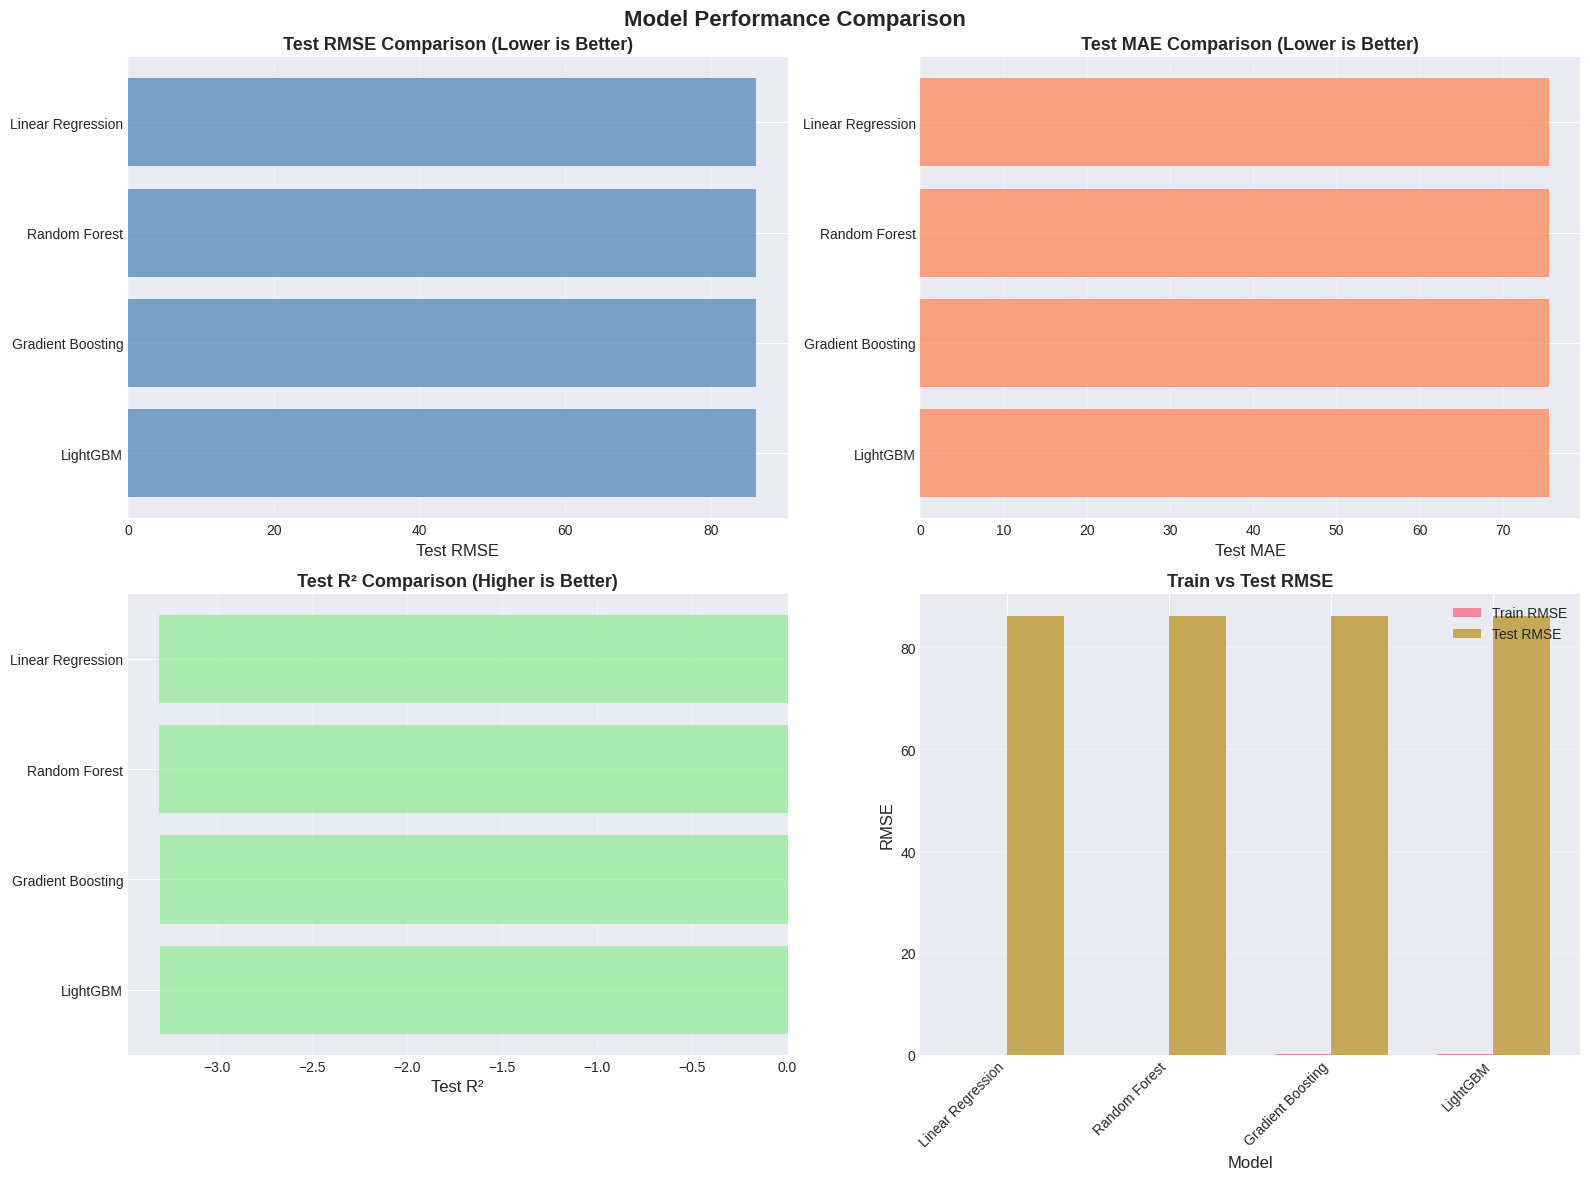

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Test RMSE
ax1 = axes[0, 0]
models_sorted = comparison_df.sort_values('Test RMSE')
ax1.barh(models_sorted['Model'], models_sorted['Test RMSE'], color='steelblue', alpha=0.7)
ax1.set_xlabel('Test RMSE', fontsize=12)
ax1.set_title('Test RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Test MAE
ax2 = axes[0, 1]
ax2.barh(models_sorted['Model'], models_sorted['Test MAE'], color='coral', alpha=0.7)
ax2.set_xlabel('Test MAE', fontsize=12)
ax2.set_title('Test MAE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Test R²
ax3 = axes[1, 0]
models_sorted_r2 = comparison_df.sort_values('Test R²', ascending=False)
ax3.barh(models_sorted_r2['Model'], models_sorted_r2['Test R²'], color='lightgreen', alpha=0.7)
ax3.set_xlabel('Test R²', fontsize=12)
ax3.set_title('Test R² Comparison (Higher is Better)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')

# Train vs Test RMSE
ax4 = axes[1, 1]
x = np.arange(len(comparison_df))
width = 0.35
ax4.bar(x - width/2, comparison_df['Train RMSE'], width, label='Train RMSE', alpha=0.8)
ax4.bar(x + width/2, comparison_df['Test RMSE'], width, label='Test RMSE', alpha=0.8)
ax4.set_xlabel('Model', fontsize=12)
ax4.set_ylabel('RMSE', fontsize=12)
ax4.set_title('Train vs Test RMSE', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### 7.2 Prediction vs Actual (Test Set)

**Purpose**: Scatter plots showing how well each model's predictions match the actual RUL values.

**What to look for:**
- **Points close to red line**: Good predictions (predicted ≈ actual)
- **Points above line**: Model overestimates RUL (predicts more cycles remaining)
- **Points below line**: Model underestimates RUL (predicts fewer cycles remaining)
- **Tight cluster**: Consistent predictions
- **Wide spread**: High variance in predictions

**Perfect prediction**: All points would lie exactly on the red diagonal line.


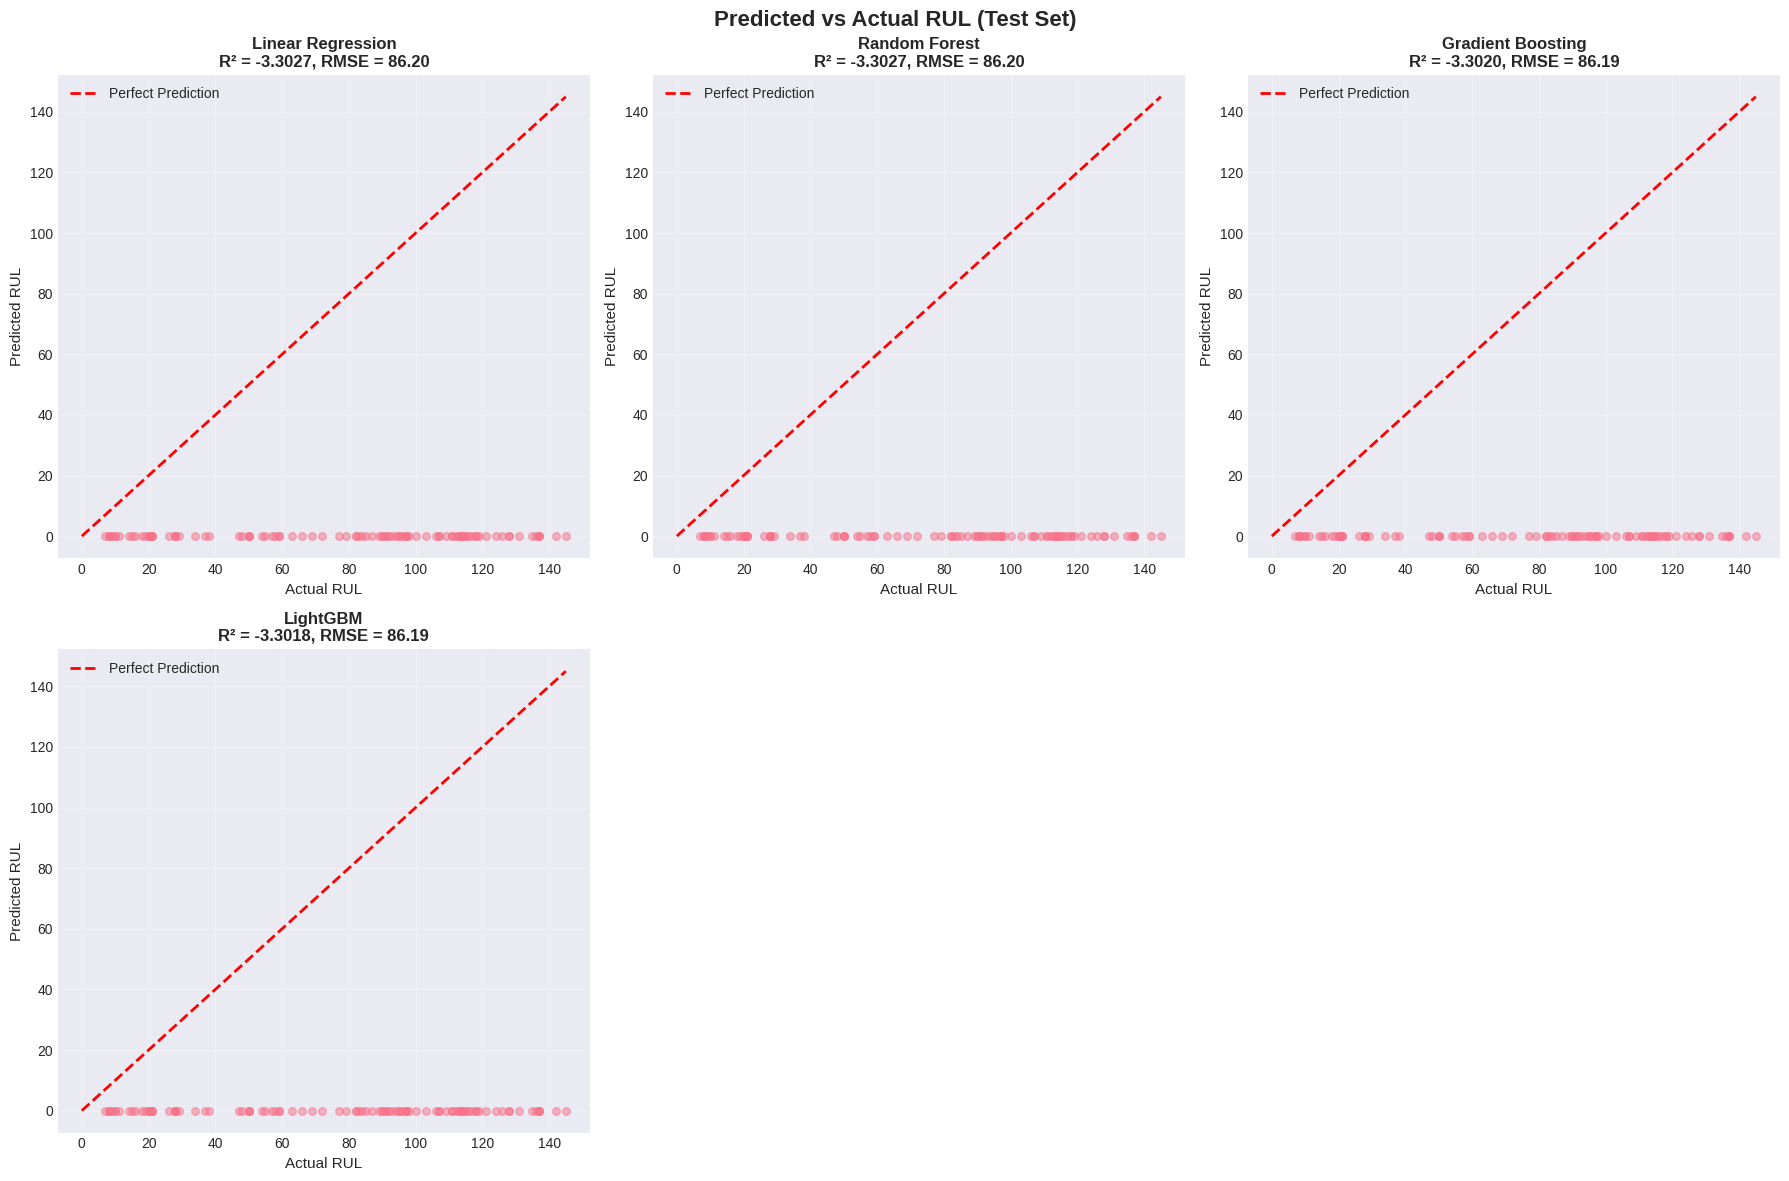

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Predicted vs Actual RUL (Test Set)', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, (model_name, result) in enumerate(results.items()):
    if idx < len(axes):
        ax = axes[idx]
        y_pred = result['y_test_pred']
        
        # Scatter plot
        ax.scatter(y_test, y_pred, alpha=0.5, s=30)
        
        # Perfect prediction line
        min_val = min(min(y_test), min(y_pred))
        max_val = max(max(y_test), max(y_pred))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
        
        ax.set_xlabel('Actual RUL', fontsize=11)
        ax.set_ylabel('Predicted RUL', fontsize=11)
        ax.set_title(f"{model_name}\nR² = {result['test_r2']:.4f}, RMSE = {result['test_rmse']:.2f}", 
                     fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(results), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


### 7.3 Residual Analysis

**Purpose**: Analyze prediction errors (residuals) to check model assumptions and identify patterns.

**What are residuals?**
- Residual = Actual RUL - Predicted RUL
- Positive residual: Model underestimated (actual > predicted)
- Negative residual: Model overestimated (actual < predicted)

**What to look for:**
- **Random scatter around zero**: Good model (errors are random)
- **Patterns or trends**: Model is missing some relationship
- **Funnel shape**: Heteroscedasticity (variance changes with prediction value)
- **Curved patterns**: Non-linear relationships not captured

**Ideal case**: Random scatter with no patterns, centered around zero.


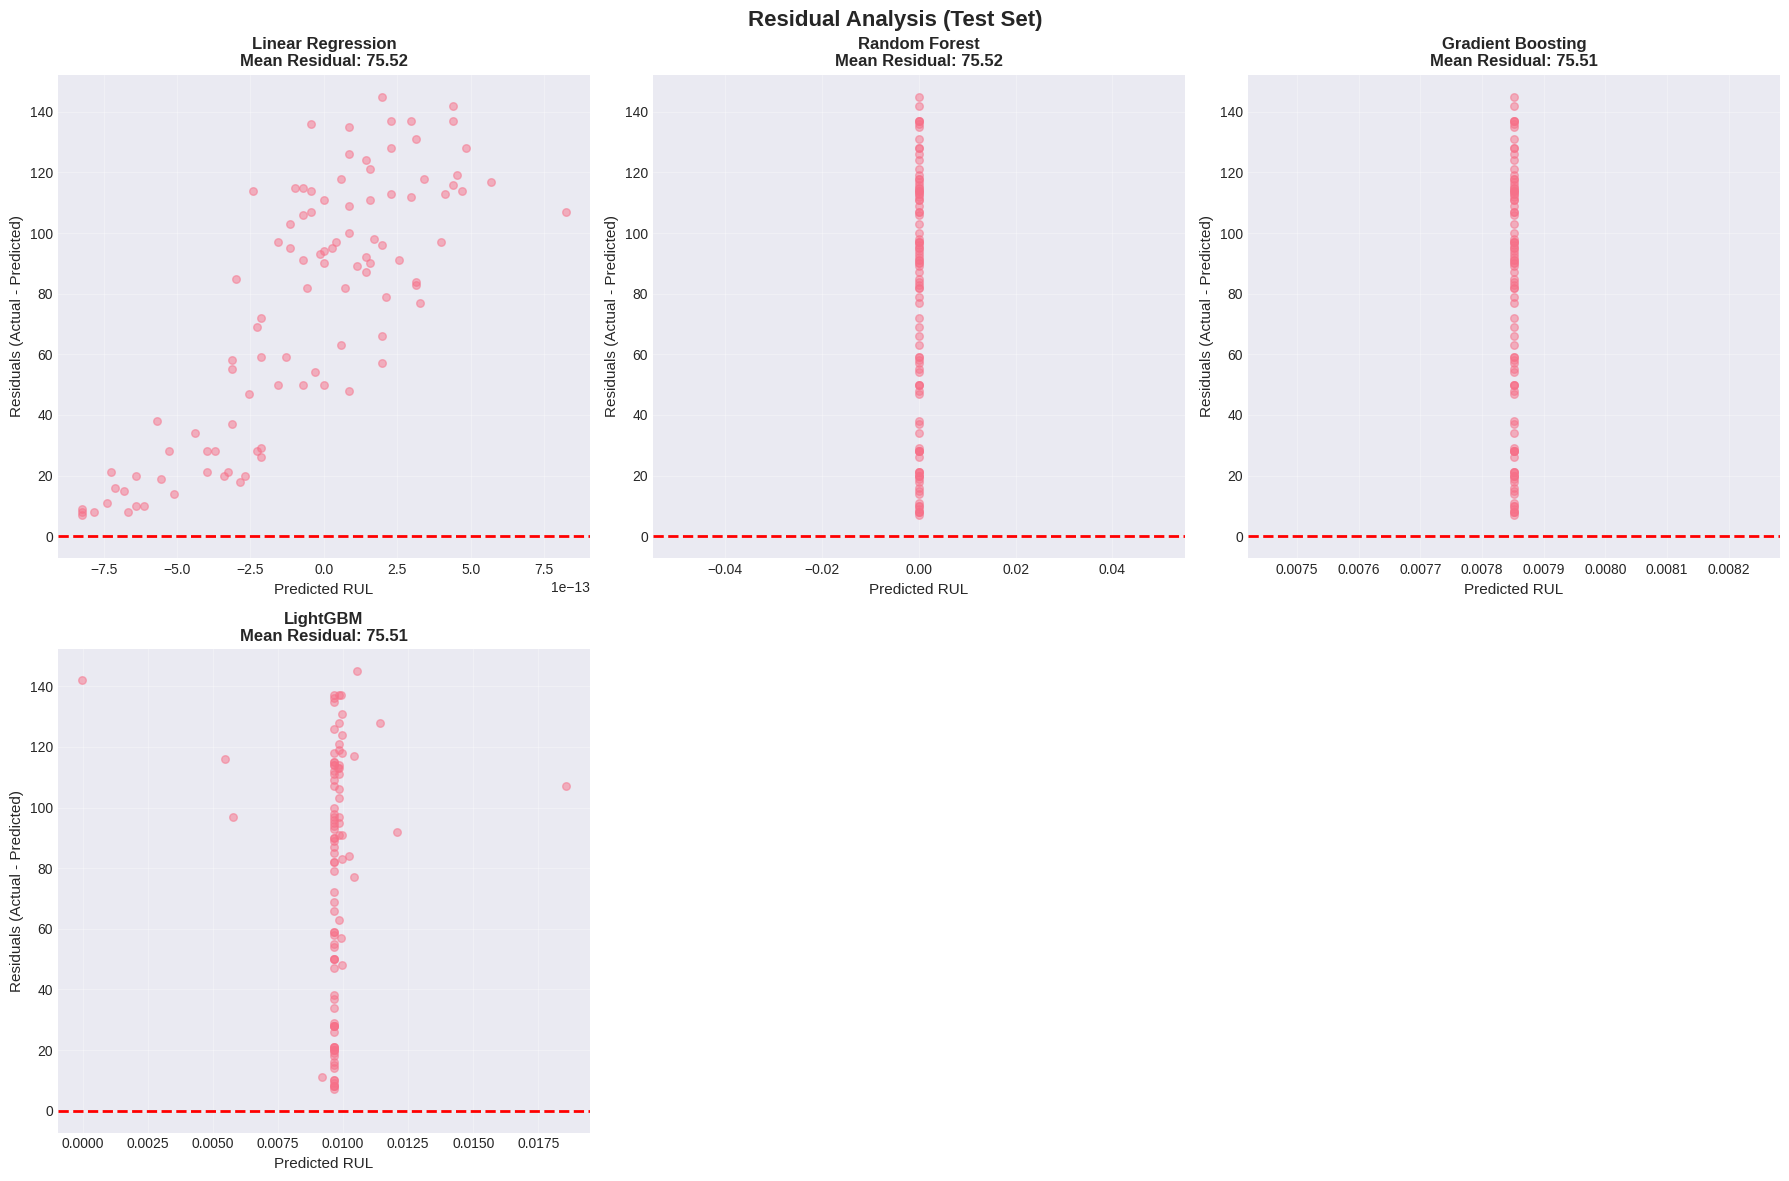

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Residual Analysis (Test Set)', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, (model_name, result) in enumerate(results.items()):
    if idx < len(axes):
        ax = axes[idx]
        y_pred = result['y_test_pred']
        residuals = y_test - y_pred
        
        # Residual plot
        ax.scatter(y_pred, residuals, alpha=0.5, s=30)
        ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
        
        ax.set_xlabel('Predicted RUL', fontsize=11)
        ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
        ax.set_title(f"{model_name}\nMean Residual: {residuals.mean():.2f}", 
                     fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(results), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


### 7.4 Feature Importance (Tree-based Models)

**Purpose**: Understand which features are most important for predictions. This helps with:
- Feature selection (removing unimportant features)
- Understanding what drives RUL predictions
- Domain knowledge validation (do important features make physical sense?)

**How Feature Importance Works:**
- Measures how much each feature contributes to reducing prediction error
- Calculated by summing the decrease in impurity (or MSE) across all splits using that feature
- Higher importance = feature is used more often and in more important splits

**Interpretation:**
- Features with high importance are critical for predictions
- Low importance features might be redundant or noisy
- Can help identify which sensors to monitor most closely


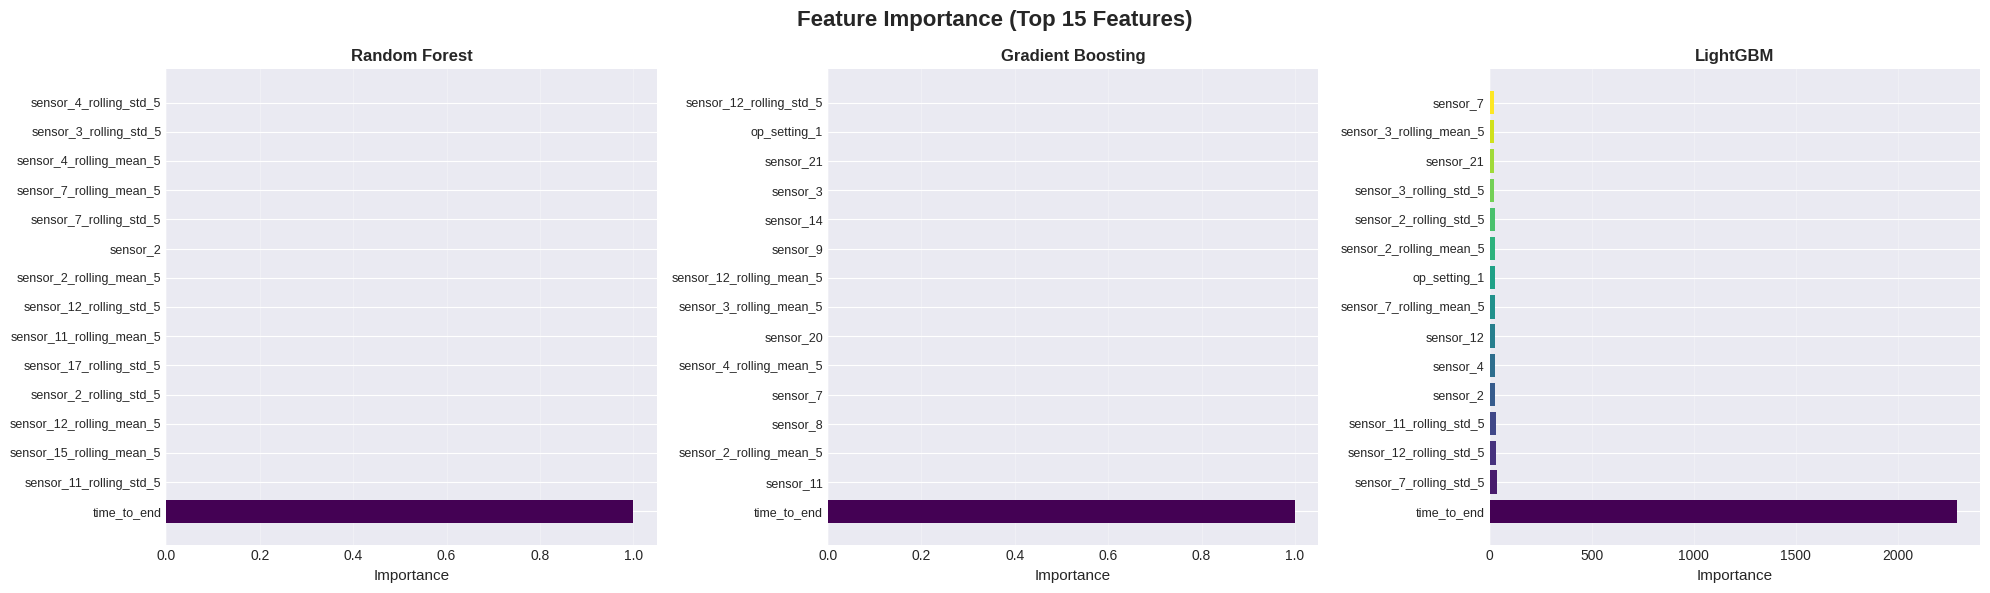

In [28]:
# Feature importance for tree-based models
tree_models = ['Random Forest', 'Gradient Boosting', 'LightGBM']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Feature Importance (Top 15 Features)', fontsize=16, fontweight='bold')

for idx, model_name in enumerate(tree_models):
    if model_name in results:
        ax = axes[idx]
        model = results[model_name]['model']
        
        # Get feature importance
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            feature_names = X_train.columns
            
            # Get top 15 features
            top_indices = np.argsort(importances)[-15:][::-1]
            top_features = [feature_names[i] for i in top_indices]
            top_importances = importances[top_indices]
            
            ax.barh(range(len(top_features)), top_importances, color=plt.cm.viridis(np.linspace(0, 1, len(top_features))))
            ax.set_yticks(range(len(top_features)))
            ax.set_yticklabels(top_features, fontsize=9)
            ax.set_xlabel('Importance', fontsize=11)
            ax.set_title(model_name, fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
